# Binary tagging revisited
seeing how well RESNET50 and transfer learning worked, it might just be beneficial to see if we can get a binary tagging model working that exceeds 0.91 F1 scores. The outcome of this notebook is not used, just a follow-experiment. We can basically fully reuse all renset componentents already developped. for 3.3. and up. As it is, the resnet learner was developed with multiclass output in mind. But given it's not that complex to write the code out to use it for a binary task, we can just implement it.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
sys.path.append('../../utils')
from  configloader import Configloader
import cnn_helpers
from database import Database
import file_io
import implot
import style



2025-05-07 23:09:35.937948: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
SHAPE = 224   #required for resnet
BATCH_SIZE = 32     #how big ar teh batches for the online learning part
MAX_EPOCHS = 100    #upper limit of epochs per learning task - 
                    #    NOTE THAT there is early stopping and lr plateau just as in nobteook 2.
CROP = True         #Based on notebook 3.2
BALANCE_TEST = True
PHASE = 'binary phase 2.0'

In [3]:
cnn_helpers.system_override()
device = cnn_helpers.system_pick_device()

System override applied - check if GPU is detected
Using GPU for deep learning.


2025-05-07 23:09:37.926474: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-05-07 23:09:40.283253: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-05-07 23:09:40.283335: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero


In [4]:
config = Configloader()
db = Database(config)
db.connect()
basedir = config.get('settings', 'image_directory')


Connection established


In [5]:
data = db.execute_query("""SELECT
                angletags.*,
                images.*
            FROM angletags 
            JOIN images ON images.id = angletags.image_id
            WHERE 
                angletags.manual_annotation = 1 """)


In [6]:
df = pd.DataFrame(data)

In [7]:
#set column "usable" to 1 if angle != crappy
df['usable'] = 1
df.loc[df['angle'] == "crappy", 'usable'] = 0

In [8]:
df.usable.sum()

7361

In [9]:
df =  cnn_helpers.cast_bbox_values(df)
df = file_io.make_absolute_path(df, basedir, 'image_path', 'abs_path', True)


In [10]:
df

,image_id,angle,manual_annotation,pk,id,listing_id,processed,use_image,certainty_of_outside_yolo,yolobox_top_left_x,yolobox_top_left_y,yolobox_bottom_right_x,yolobox_bottom_right_y,area,confidence,usable,abs_path
0,524,rearleft,1,1,524,42,1,1,-1,1,118,658,500,0.595859,0.91561,1,/home/frederic/Documents/automotive_image_data...
1,1330,crappy,1,2,1330,96,1,0,-1,-1,-1,-1,-1,-1,-1,0,/home/frederic/Documents/automotive_image_data...
2,1974,rearright,1,3,1974,148,1,1,-1,140,150,687,555,0.525252,0.815314,1,/home/frederic/Documents/automotive_image_data...
3,2469,crappy,1,4,2469,188,1,1,-1,2,161,422,564,0.711035,0.857692,0,/home/frederic/Documents/automotive_image_data...
4,2510,crappy,1,5,2510,193,1,0,-1,-1,-1,-1,-1,-1,-1,0,/home/frederic/Documents/automotive_image_data...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,586504,crappy,1,20001,586504,37301,1,0,-1,-1,-1,-1,-1,-1,-1,0,/home/frederic/Documents/automotive_image_data...
19996,1222264,crappy,1,20002,1222264,78605,1,0,-1,-1,-1,-1,-1,-1,-1,0,/home/frederic/Documents/automotive_image_data...
19997,1331406,crappy,1,20003,1331406,85742,1,0,-1,-1,-1,-1,-1,-1,-1,0,/home/frederic/Documents/automotive_image_data...
19998,87577,crappy,1,20004,87577,5769,1,0,-1,-1,-1,-1,-1,-1,-1,0,/home/frederic/Documents/automotive_image_data...


The angletagger does not generate duplicates, so I don't need to clean it. 

## Send to RESNET

In [11]:
basename = 'binary_revisited'


In [12]:
basefolder = config.get('directories', 'binary_dir')
# don't store it in the same directore, this is not a structural part of the code, just a 2.0 idea, thsi is fine. 
basefolder += '_revisited' 
basefolder = os.path.join(
    config.get('directories', 'root_dir'), 
    basefolder
)
os.makedirs(basefolder, exist_ok=True)
basefolder


'/home/frederic/Documents/automotive_project/models/bin_models_revisited'

In [13]:
# now the train,test, val are always the same! (the custom ttvspliter uses indexes.)
# now we can rerun the notebook if we want for implots without going through training again.
df_s = cnn_helpers.shuffle_df(df, rs = 42)

In [14]:
df_train, df_test, df_val = cnn_helpers.train_test_val_splitter(
                                df_s, 
                                70,
                                20,
                                10, 
                                ['usable']
                            )
df_train = df_train.reset_index()
df_test = df_test.reset_index()
df_val = df_val.reset_index()

In [15]:
print(len(df_train), len(df_test), len(df_val), len(df_s))

14000 4000 2000 20000


In [16]:
drops = ['angle', 'manual_annotation', 'pk', 'id', 'listing_id', 'processed', 'use_image', 'certainty_of_outside_yolo', 'area', 'confidence', 'image_id']
X_train, y_train = cnn_helpers.get_X_y(df_train, 'usable', drops)
X_test, y_test = cnn_helpers.get_X_y(df_test, 'usable', drops)

In [17]:
crop_options = [True, False]
basename = 'Binary tagger_revisited_'
for crop in crop_options: 
    name = f'{basename} - CROP={crop}.keras'
    targetfolder = os.path.join(basefolder, str(crop))
    file_save = os.path.join(targetfolder,name)
    if os.path.exists(file_save):
        print(f'{name} already exists - skipping training')
        continue
    os.makedirs(targetfolder, exist_ok=True)#since infer_cnn expects one model/json file per folder
    model = cnn_helpers.resnet_learner(X_train, X_test, y_train, y_test, SHAPE, crop, targetfolder, BATCH_SIZE, MAX_EPOCHS)
    file_io.wipe_folder(targetfolder)
    model.save(file_save)





Binary tagger_revisited_ - CROP=True.keras already exists - skipping training
Binary tagger_revisited_ - CROP=False.keras already exists - skipping training


## model assesment against df_val

In [18]:
results = {}
for crop_test in [True, False]:
    for crop_model in os.listdir(basefolder): 
        crop = crop_model.lower()=='true'
        folder = os.path.join(basefolder, crop_model)
        resultname = f'infer={int(crop_test)}-train={int(crop)}'
        p,a,decode = cnn_helpers.infer_cnn(folder, df_val, crop_test, SHAPE, return_labels=False, target='usable')
        results[resultname] = {
                'predicts_raw':p,
                'predicts': np.argmax(p, axis=1),
                'actuals':a,
                'decoder': decode
                }

2025-05-07 23:09:40.998729: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-05-07 23:09:40.998855: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-05-07 23:09:40.998907: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-05-07 23:09:40.998993: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-05-07 23:09:40.999044: I external/local_xla/xla/stream_executor/rocm/rocm_executor.

In [19]:
full_metrics = {}
cms = {}
for approach, outcome in results.items(): 
    act = outcome['actuals']
    pred = outcome['predicts']
    cm = implot.make_cm(act, pred, ['crappy','good'], embed=True)
    cms[approach] = cm
    full_metrics[approach] = implot.quick_metrics(act, pred)

In [20]:
fig = implot.plot_quick_metrics(full_metrics)
fig.update_layout(
    height=800,
    width=1400,
    title_text='Binary tagger using RESNET (0=uncropped; 1=crop)',
    showlegend=False
)


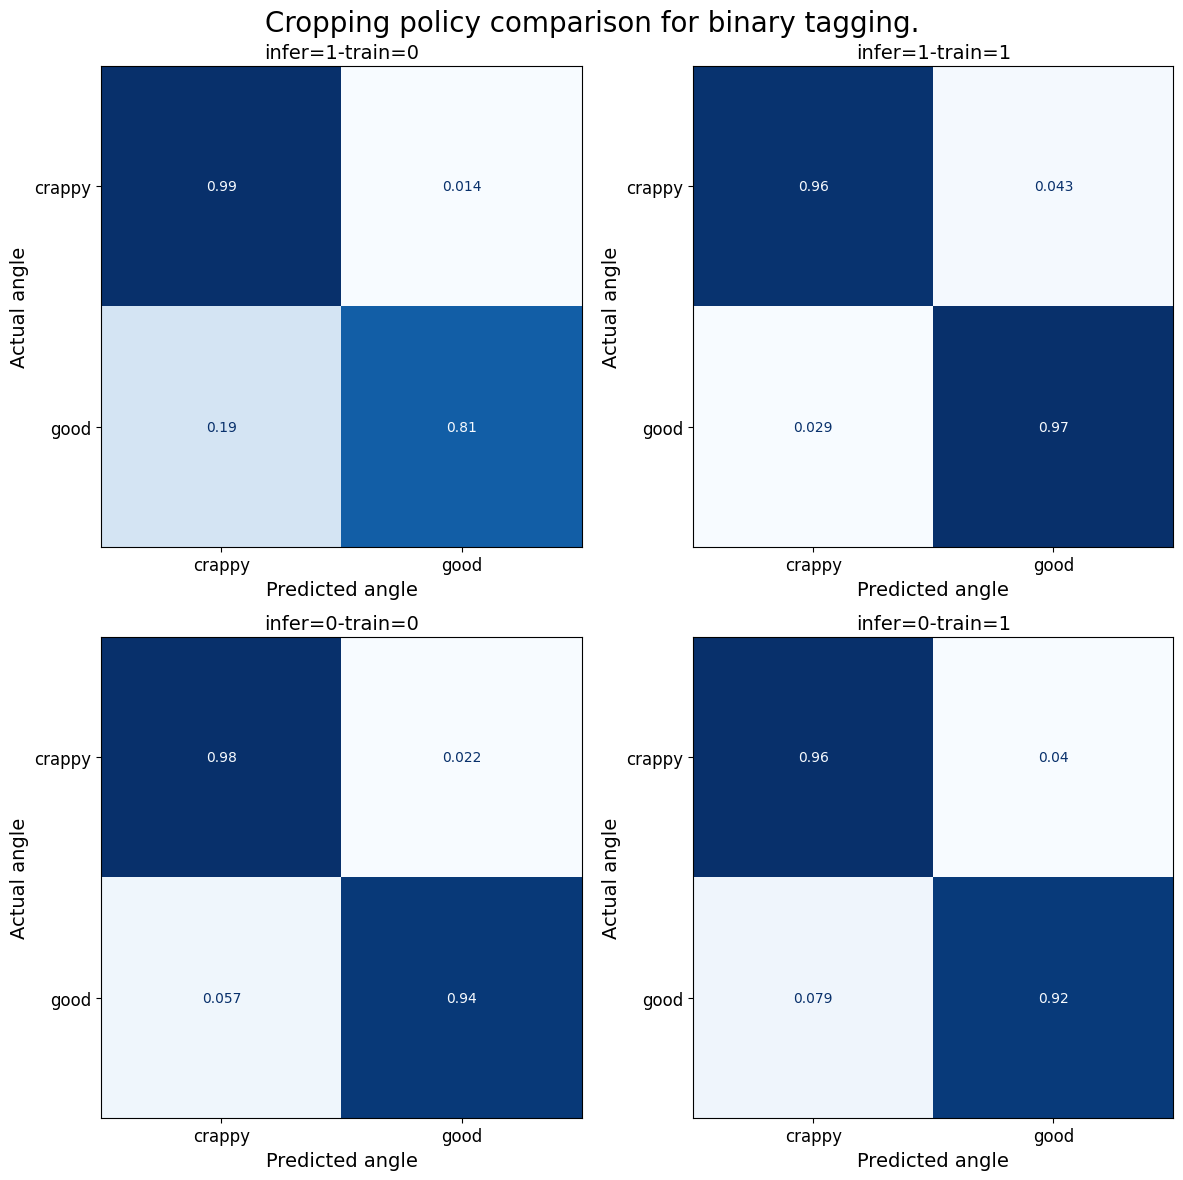

In [21]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(12, 12))
axs = axs.flatten()
idx = 0
for ax, (title, cm_disp) in zip(axs, cms.items()):
    cm_disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title, fontsize=14)
    ax.set_xticklabels(['crappy', 'good'], fontsize=12)
    ax.set_yticklabels(['crappy', 'good'], fontsize=12)
    ax.set_xlabel("Predicted angle", fontsize=14)
    ax.set_ylabel("Actual angle", fontsize=14)
plt.suptitle('Cropping policy comparison for binary tagging.', fontsize=20)
plt.tight_layout()


In the original binary tagger, the highest F1 score was 92.6%; here we've improved to 96.2% of the best performing approach; this approach was to NOT crop during training and to NOT crop when infering. 

depending on the goal you could choose two models: 
- As few as possible bad images go though: pick a hybrid approach ==> `infer=1-train=0`: The model is trained on UNCROPPED images, but for predictions it's fed cropped images. This is the model that performed the worst in the barcharts. Reason: it's embarassingly high rate of false negatives (usable images, that are marked as unusable. - 19%). The rate of false positives (bad image, that is marked as usable is only 1.4%)
- However, when we choose the next best model when looking at the false positives; we see that a non-hybrid approach: `infer=0-train=0`: Do NOT crop for training and do NOT crop for inferring. This model has 2.2% false positives, and only 5.7% false negatives. The True positives went up from 81% to 94% at a cost only 0.8% more false positives.

Given the very restrictive definition that was applied during the Flask-tagging phase, this 0.8% may included images of cars that are partly cropped or have an open door - I'll take this risk and consider `infer=0-train=0` the best approach. 

In [22]:
infer_crop = False
train_crop = False
selected_approach = f'infer={int(infer_crop)}-train={int(train_crop)}'

r = results[selected_approach]['predicts']
df_val[selected_approach] = r

In [23]:
df_val_wrong = df_val.loc[df_val.usable != df_val[selected_approach]].reset_index()
df_val_wrong['titles'] = (
    'act:' + df_val_wrong['usable'].astype(str) +
    ', pred:' + df_val_wrong[selected_approach].astype(str)
)
display(df_val_wrong)

,level_0,index,image_id,angle,manual_annotation,pk,id,listing_id,processed,use_image,...,yolobox_top_left_x,yolobox_top_left_y,yolobox_bottom_right_x,yolobox_bottom_right_y,area,confidence,usable,abs_path,infer=0-train=0,titles
0,20,17951,1387402,rearright,1,10144,1387402,89417,1,1,...,62,74,618,480,0.535612,0.902208,1,/home/frederic/Documents/automotive_image_data...,0,"act:1, pred:0"
1,89,12573,563942,crappy,1,4356,563942,35852,1,1,...,68,141,652,458,0.439339,0.729173,0,/home/frederic/Documents/automotive_image_data...,1,"act:0, pred:1"
2,136,14915,1371729,left,1,10772,1371729,88267,1,1,...,21,121,689,507,0.612293,0.901606,1,/home/frederic/Documents/automotive_image_data...,0,"act:1, pred:0"
3,170,13936,933284,right,1,6693,933284,60343,1,0,...,-1,-1,-1,-1,-1,-1,1,/home/frederic/Documents/automotive_image_data...,0,"act:1, pred:0"
4,184,9649,557060,frontleft,1,3233,557060,35366,1,1,...,2,2,695,562,0.922424,0.917037,1,/home/frederic/Documents/automotive_image_data...,0,"act:1, pred:0"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,1751,2995,904121,rear,1,3981,904121,58227,1,0,...,-1,-1,-1,-1,-1,-1,1,/home/frederic/Documents/automotive_image_data...,0,"act:1, pred:0"
66,1811,12380,579137,crappy,1,8774,579137,36903,1,1,...,21,93,733,492,0.674693,0.723928,0,/home/frederic/Documents/automotive_image_data...,1,"act:0, pred:1"
67,1893,14570,1433919,crappy,1,13009,1433919,92826,1,0,...,-1,-1,-1,-1,-1,-1,0,/home/frederic/Documents/automotive_image_data...,1,"act:0, pred:1"
68,1945,11183,727474,rearleft,1,16606,727474,46672,1,1,...,6,25,749,530,0.88952,0.777085,1,/home/frederic/Documents/automotive_image_data...,0,"act:1, pred:0"


In [24]:
df_val.usable.mean(), df_val[selected_approach].mean()      #just about boenk erop, that's good!

(0.368, 0.361)

In [25]:
#false positives (what is a bad image and predicted as good)
print('FP', len(df_val.query("usable==0&`infer=0-train=0`==1")))
print('FN', len(df_val.query("usable==1&`infer=0-train=0`==0")))
print('total items in df_val', len(df_val))

FP 28
FN 42
total items in df_val 2000


28 false positives out of 2000; it's higher than the 1% aim; but a much better start for an individual model; the lowest model that was usable in the original binary tagger had 64 false positives. I think it's safe to say that RESNET50 worked better than implementing layers on my own. 

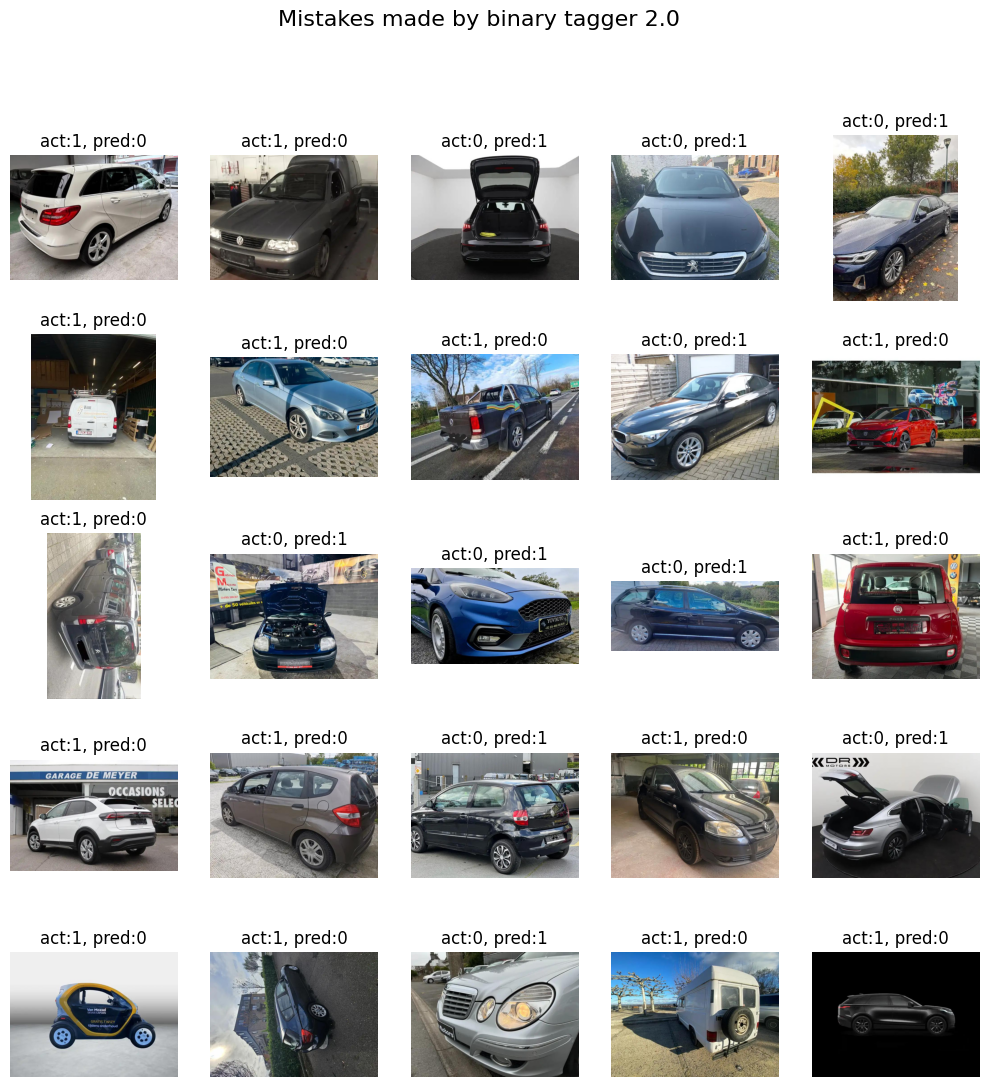

In [26]:
#let's see what went wrong: 
implot.plot_images_as_grid(df_val_wrong['abs_path'], 'Mistakes made by binary tagger 2.0', n=5, imtitles= df_val_wrong['titles'])

let's test one more thing: My original binary tagging algorithm was quite far from the original 36% usability rate - it got to about 4million out of 15.6 indicating we're having a lot of false negatives(act:good; pred:bad). Let's take 10000 random images from the SQL database (where countrycode <> B as B was used to train the binary stuff on - so we are absolutely, postively, indisputably working with unseen data (i.e. logo's of belgian dealerships etc...)) and see how much closer we can get to a usability rate of 36%

In [27]:
query = 'SELECT * FROM images JOIN listings on images.listing_id = listings.id WHERE listings.countrycode <> "B" ORDER BY RAND() LIMIT 10000'
data_unseen = db.execute_query(query)

In [28]:
unseen_df = pd.DataFrame(data_unseen)
unseen_df =  cnn_helpers.cast_bbox_values(unseen_df)
unseen_df = file_io.make_absolute_path(unseen_df, basedir, 'image_path', 'abs_path', True)
unseen_df.sample(5)

,id,listing_id,processed,use_image,certainty_of_outside_yolo,yolobox_top_left_x,yolobox_top_left_y,yolobox_bottom_right_x,yolobox_bottom_right_y,area,...,variant_id,generation_id,motortype_id,trim_id,shelltype,doorcount,weight,normlabel,countrycode,abs_path
6394,12775245,720301,1,0,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,-1,Bestelwagen,4.0,1.0,-1,NL,/home/frederic/Documents/automotive_image_data...
1752,14785401,799450,1,0,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,-1,Stadswagen,5.0,839.0,EURO6,NL,/home/frederic/Documents/automotive_image_data...
6755,5853273,355351,1,0,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,-1,Monovolume,4.0,2.0,EURO6,D,/home/frederic/Documents/automotive_image_data...
7343,9967348,601559,1,1,-1,83,110,651,490,0.513121,...,-1,-1,-1,-1,Stadswagen,5.0,-1,-1,F,/home/frederic/Documents/automotive_image_data...
3670,14280220,779643,1,0,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,-1,Cabriolet,2.0,1.0,EURO4,NL,/home/frederic/Documents/automotive_image_data...


In [29]:
folder = os.path.join(basefolder, str(train_crop))
#let it return the id as actuals - we do not need it
p,a,decode = cnn_helpers.infer_cnn(folder, unseen_df, infer_crop, SHAPE, return_labels=False, target='id')


In [30]:
unseen_df['predictions'] = np.argmax(p, axis=1)

In [31]:
unseen_df.predictions.mean()    #about 30% depending on the run

0.3053

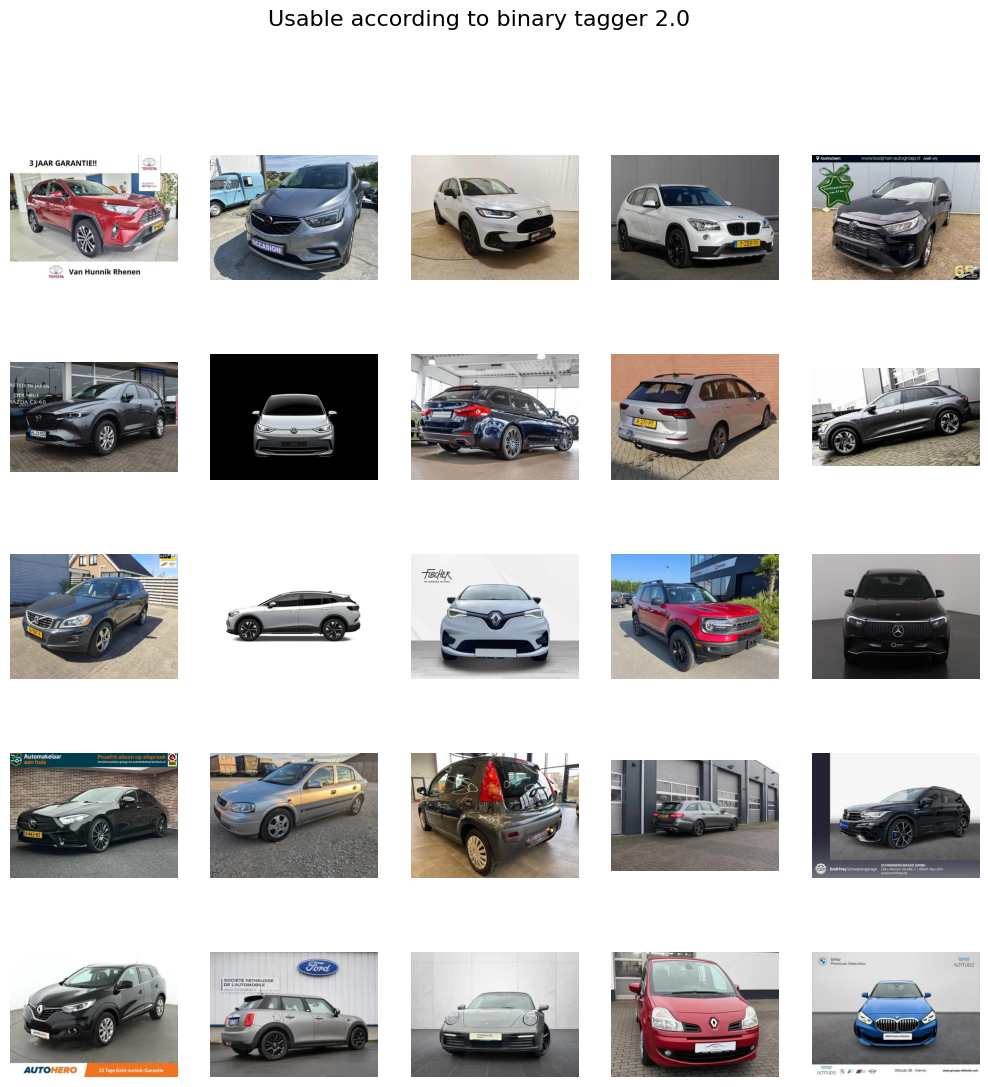

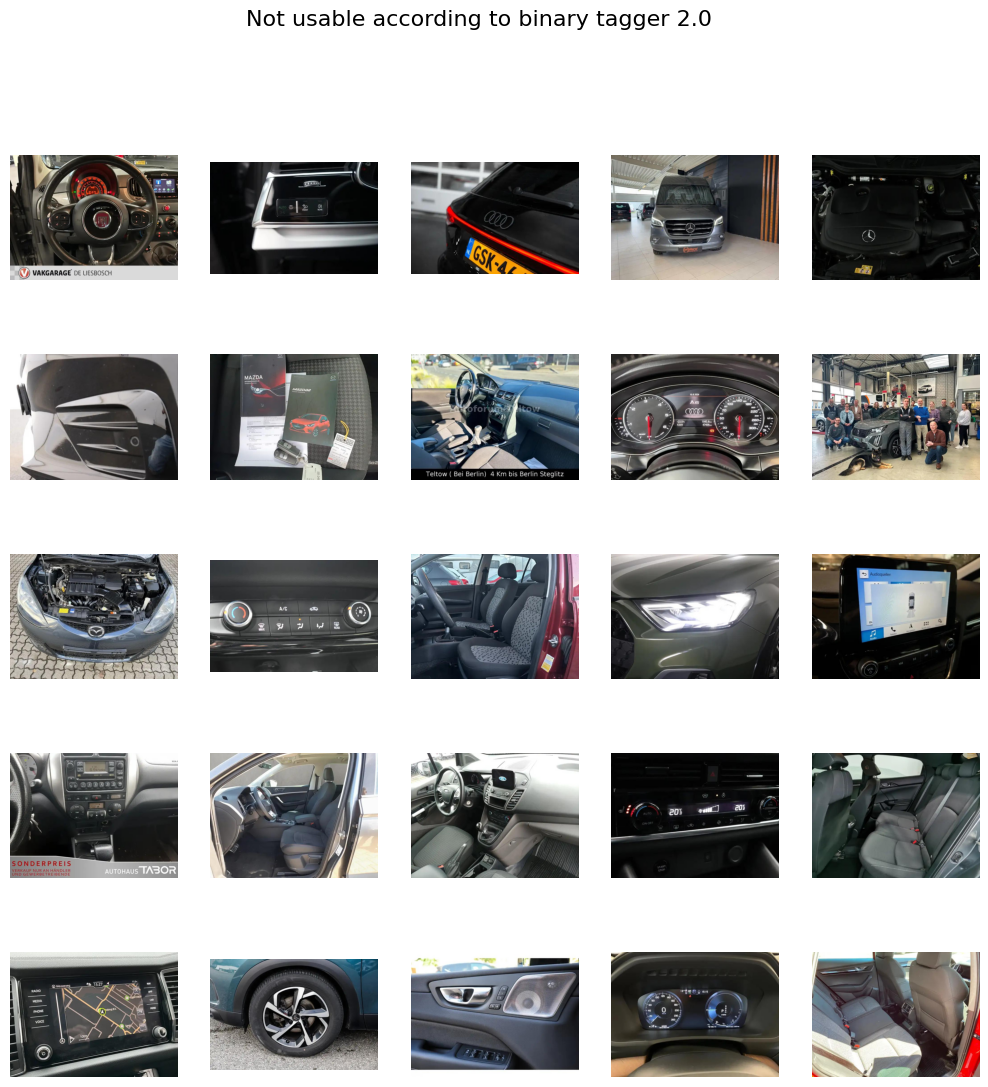

In [32]:
implot.plot_images_as_grid(unseen_df.query('predictions==1')['abs_path'], 'Usable according to binary tagger 2.0', n=5)
implot.plot_images_as_grid(unseen_df.query('predictions==0')['abs_path'], 'Not usable according to binary tagger 2.0', n=5)


## Impact of binary tagger 2.0

There's higher keep rate and less false positives when comparing binary tagger 2.0 vs any of the original binary tagging alghorithms. For high-frequency brands I don't expect a lot of impact, for low frequency brands (Alpine, Lotus) it'd mean we get to start the trainingphase with more viariation in the images and more images to choose from to augmentate. Generalization for these less common brands would increase. We could also expllore moving the treshold away to determin usability. But both suggestions are for now considered out of scope. 